# EDA for Tradeoff Analysis and Result Interpretation
### Load the final results CSV file

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import pi

# Set professional aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
colors = {'gru': '#1f77b4', 'lstm': '#2ca02c', 'cnn': '#d62728', 'dnn': '#9467bd'}

# Load the evaluation metrics (final results)
file_path = '../results/preprocessed_proposal/ablation_win16_kdeTrue_AR_seed61/final_evaluation_metrics.csv'
df = pd.read_csv(file_path, index_col=0)

# Strip any accidental hidden spaces from the column names and index (row names)
df.columns = df.columns.str.strip()
df.index = df.index.str.strip()

# Ensure all data is numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Final Evaluation Data Loaded Successfully!")
print("Cleaned Columns:", df.columns.tolist())
display(df)

Final Evaluation Data Loaded Successfully!
Cleaned Columns: ['D2D MAE', 'Cell MAE', 'D2D RMSE', 'Cell RMSE', 'D2D PICP%', 'Cell PICP%', 'D2D MPIW (dB)', 'Cell MPIW (dB)', 'R2 D2D', 'R2 Cell', 'Params', 'Mem (KB)', 'FLOPs', 'Inference (ms)', 'Avg Tput (Mbps)', 'Spectral Eff (bps/Hz)', 'Switch Rate (%)', 'Avg D2D Stay (s)']


,D2D MAE,Cell MAE,D2D RMSE,Cell RMSE,D2D PICP%,Cell PICP%,D2D MPIW (dB),Cell MPIW (dB),R2 D2D,R2 Cell,Params,Mem (KB),FLOPs,Inference (ms),Avg Tput (Mbps),Spectral Eff (bps/Hz),Switch Rate (%),Avg D2D Stay (s)
,,,,,,,,,,,,,,,,,,
gru,6.01,6.14,7.60,7.76,94.7,94.2,29.73,31.13,0.496,0.470,41857.0,163.5,83714.0,0.27,25.00,0.2500,2.36,41.6
lstm,6.49,6.44,8.13,8.13,95.4,93.5,32.23,32.47,0.424,0.418,208513.0,814.5,417026.0,0.30,27.15,0.2715,1.89,48.9
cnn,6.13,6.35,7.82,8.02,95.6,93.7,31.43,32.86,0.448,0.449,42305.0,165.3,84610.0,2.66,24.97,0.2497,2.38,39.4
dnn,6.07,6.38,7.68,8.09,94.3,93.7,29.99,32.23,0.468,0.440,121089.0,473.0,242178.0,1.11,28.30,0.2830,3.17,31.8
pure_d2d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.86,0.2286,0.00,99.0
pure_cellular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.03,0.1203,1.01,0.0
random,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.33,0.1533,49.63,1.9
sinr_threshold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.92,0.2392,10.03,1.3


### Generate plots to compare DL models in terms of metrics

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_mae.png


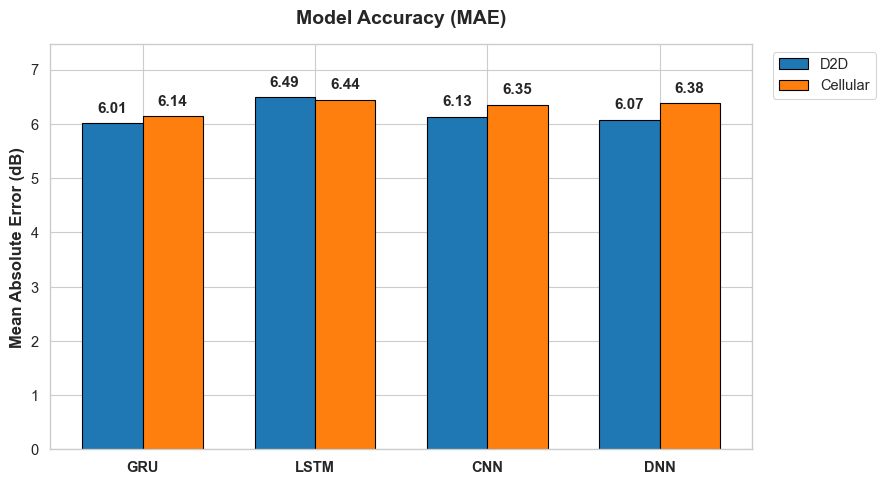

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_rmse.png


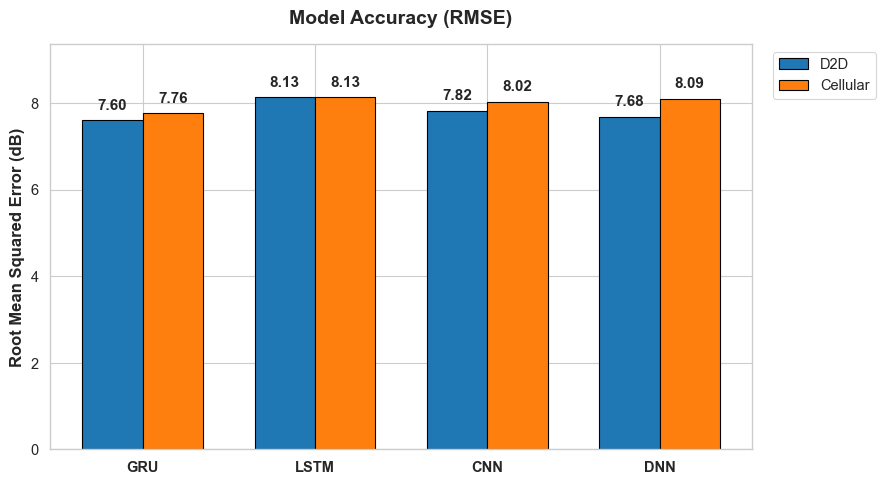

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_r2.png


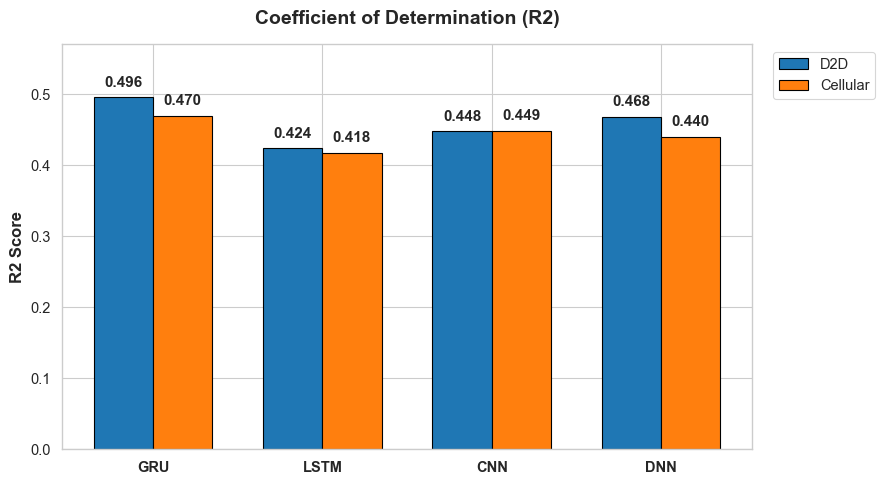

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_picp.png


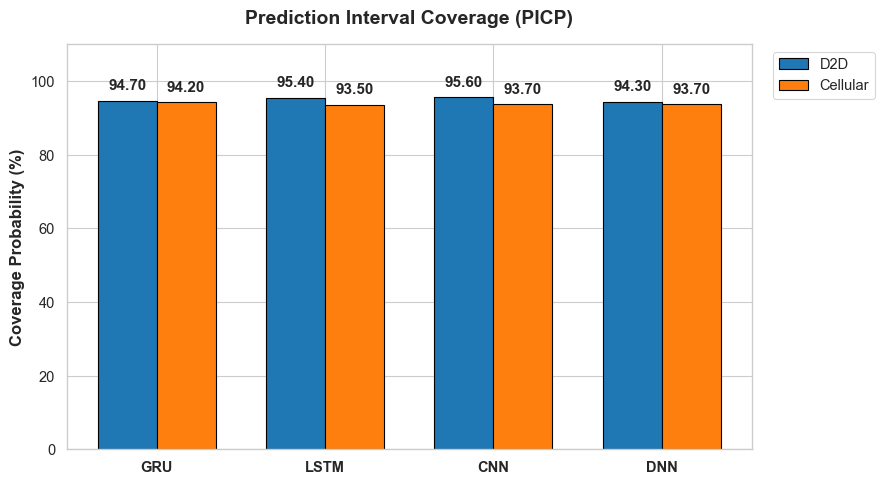

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_mpiw.png


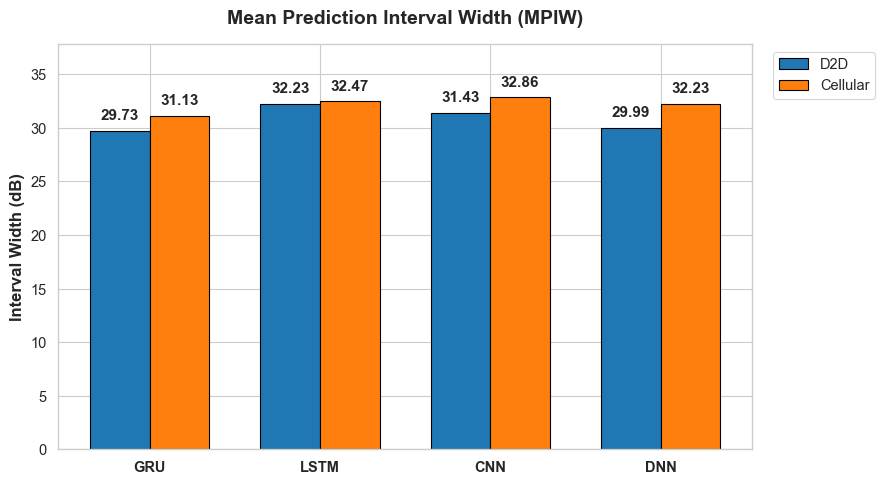

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_params.png


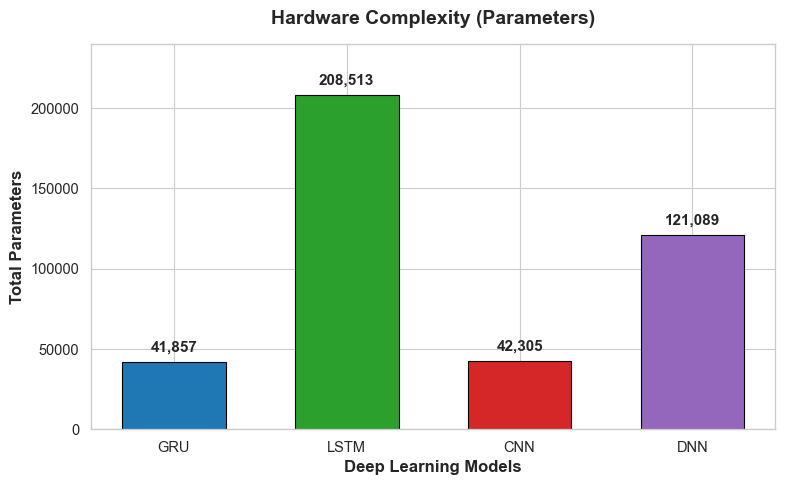

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_memory.png


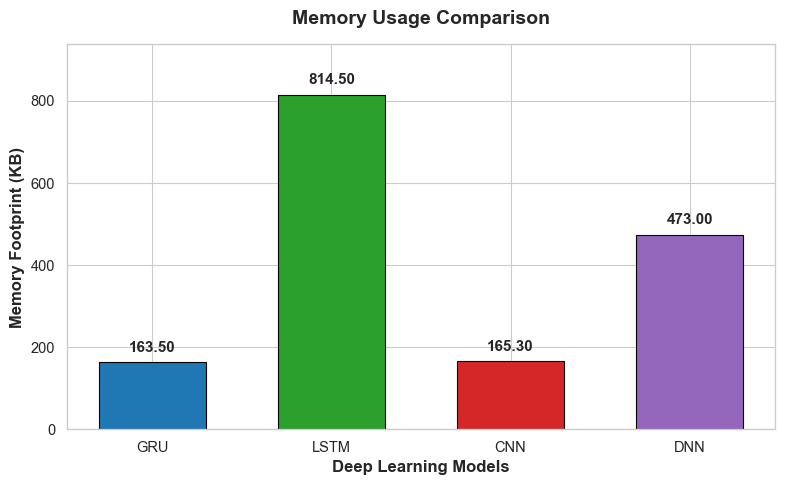

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_flops.png


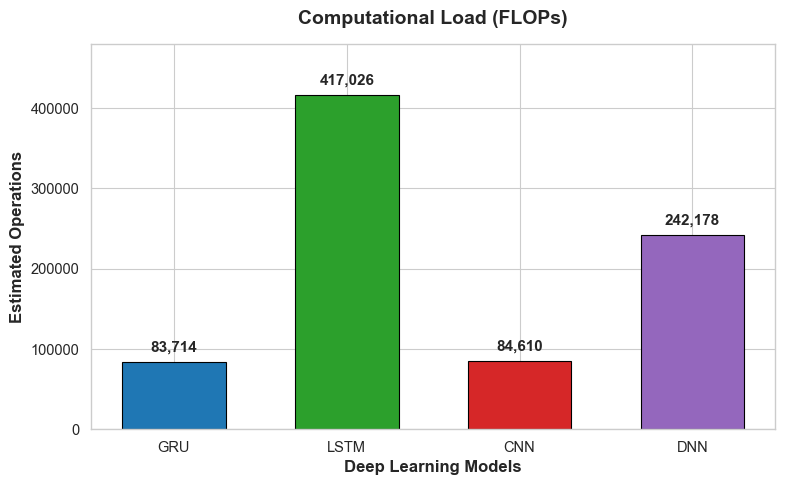

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_inference.png


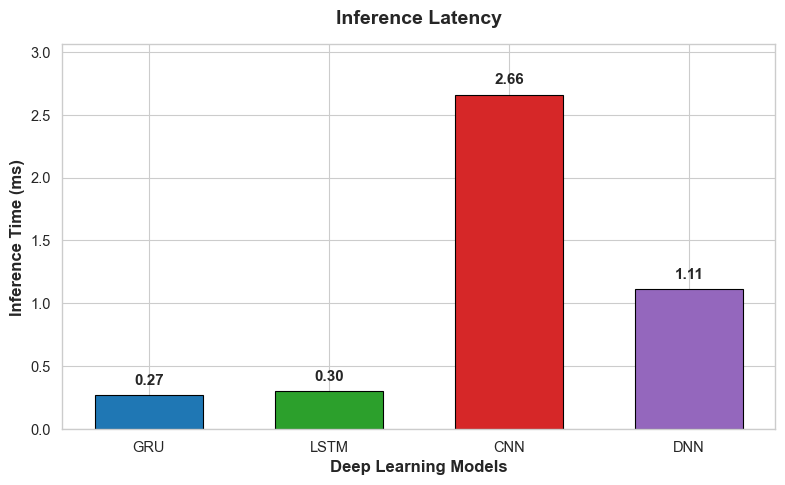

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_throughput.png


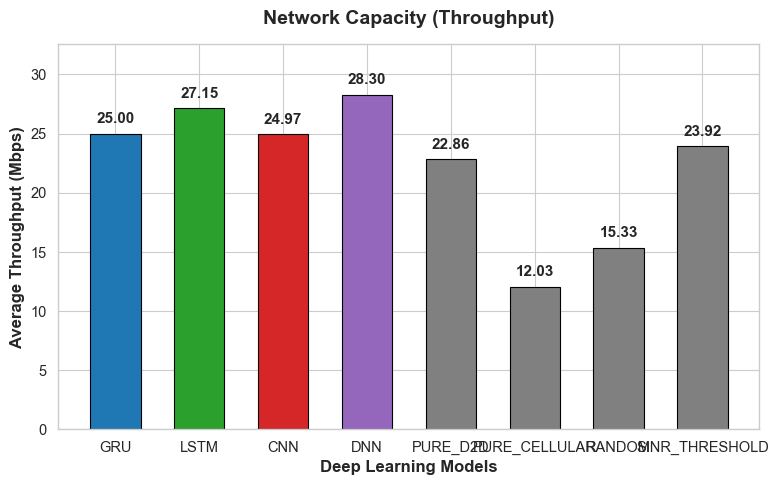

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_spectral_eff.png


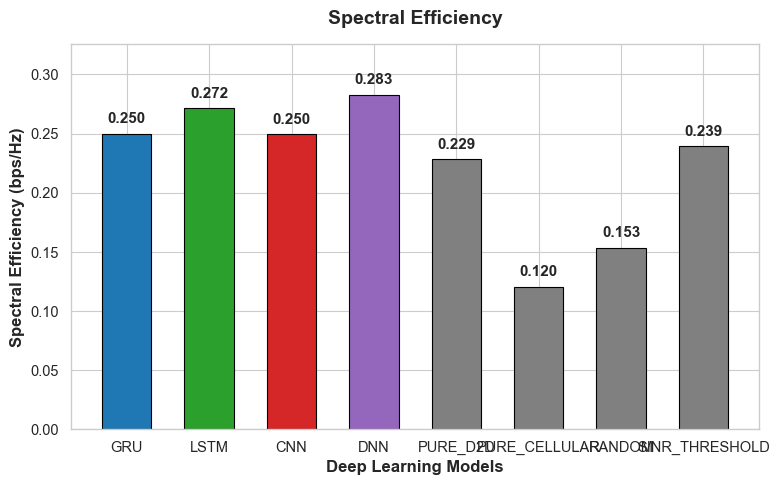

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_switch_rate.png


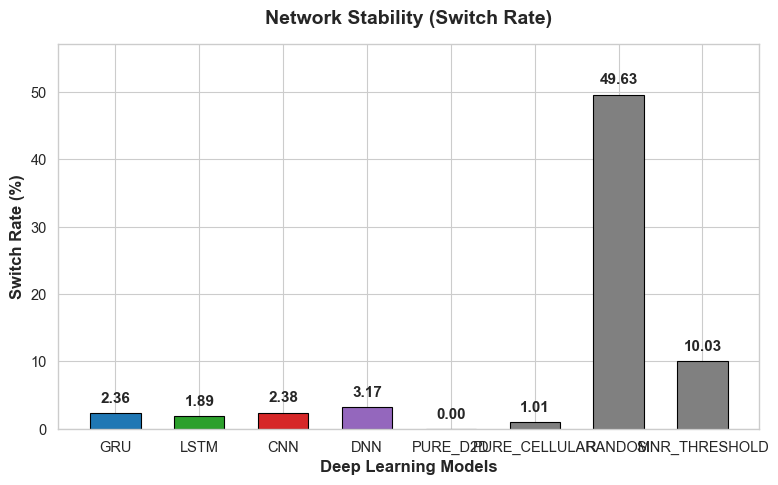

✓ Saved: ../results/preprocessed_proposal/standalone_graphs\standalone_d2d_stay.png


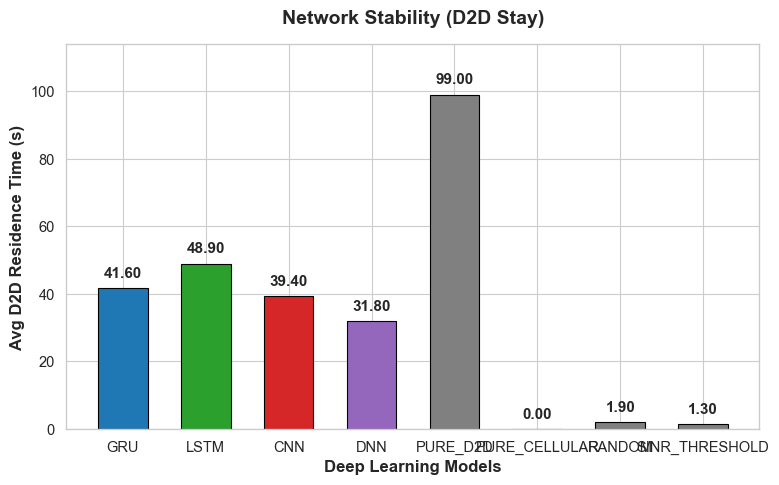

In [3]:
# Ensure the directory exists for standalone graphs
save_dir = '../results/preprocessed_proposal/standalone_graphs'
os.makedirs(save_dir, exist_ok=True)

# Dual Metrics (Grouped Bar Charts for D2D vs Cellular)
dual_metrics = [
    ('D2D MAE', 'Cell MAE', 'Mean Absolute Error (dB)', 'Model Accuracy (MAE)', 'standalone_mae.png'),
    ('D2D RMSE', 'Cell RMSE', 'Root Mean Squared Error (dB)', 'Model Accuracy (RMSE)', 'standalone_rmse.png'),
    ('R2 D2D', 'R2 Cell', 'R2 Score', 'Coefficient of Determination (R2)', 'standalone_r2.png'),
    ('D2D PICP%', 'Cell PICP%', 'Coverage Probability (%)', 'Prediction Interval Coverage (PICP)', 'standalone_picp.png'),
    ('D2D MPIW (dB)', 'Cell MPIW (dB)', 'Interval Width (dB)', 'Mean Prediction Interval Width (MPIW)', 'standalone_mpiw.png')
]

# Single Metrics (Standard Bar Charts)
single_metrics = [
    ('Params', 'Total Parameters', 'Hardware Complexity (Parameters)', 'standalone_params.png'),
    ('Mem (KB)', 'Memory Footprint (KB)', 'Memory Usage Comparison', 'standalone_memory.png'),
    ('FLOPs', 'Estimated Operations', 'Computational Load (FLOPs)', 'standalone_flops.png'),
    ('Inference (ms)', 'Inference Time (ms)', 'Inference Latency', 'standalone_inference.png'),
    ('Avg Tput (Mbps)', 'Average Throughput (Mbps)', 'Network Capacity (Throughput)', 'standalone_throughput.png'),
    ('Spectral Eff (bps/Hz)', 'Spectral Efficiency (bps/Hz)', 'Spectral Efficiency', 'standalone_spectral_eff.png'),
    ('Switch Rate (%)', 'Switch Rate (%)', 'Network Stability (Switch Rate)', 'standalone_switch_rate.png'),
    ('Avg D2D Stay (s)', 'Avg D2D Residence Time (s)', 'Network Stability (D2D Stay)', 'standalone_d2d_stay.png')
]

# Create an ordered list of colors based on the current DataFrame index
ordered_colors = [colors.get(model_name.lower(), '#808080') for model_name in df.index]
x = np.arange(len(df.index))
width = 0.35

# 1. Plot Dual Metrics (Grouped Bars)
for col_d2d, col_cell, ylabel, title, filename in dual_metrics:
    if col_d2d not in df.columns or col_cell not in df.columns:
        print(f"⚠️ Skipping {title} - columns not found in DataFrame. Check evaluate_system.py dictionary!")
        continue
        
    # FIX: Filter out rows (baselines) that have NaN values for these specific prediction metrics
    valid_df = df.dropna(subset=[col_d2d, col_cell])
    
    # Use the filtered length for the x-axis
    x_filtered = np.arange(len(valid_df.index))
    
    # Shrink figsize slightly since there are fewer columns now
    fig, ax = plt.subplots(figsize=(9, 5)) 
    
    rects1 = ax.bar(x_filtered - width/2, valid_df[col_d2d], width, label='D2D', color='#1f77b4', edgecolor='black')
    rects2 = ax.bar(x_filtered + width/2, valid_df[col_cell], width, label='Cellular', color='#ff7f0e', edgecolor='black')
    
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x_filtered)
    
    # Format labels nicely based only on the valid models
    ax.set_xticklabels([name.replace('_', ' ').upper() for name in valid_df.index], fontweight='bold')
    
    # Dynamic Y-Axis Scaling
    y_max = max(valid_df[col_d2d].max(), valid_df[col_cell].max())
    y_min = min(valid_df[col_d2d].min(), valid_df[col_cell].min())
    
    pad_upper = y_max * 0.15 if y_max > 0 else 0
    pad_lower = y_min * 0.15 if y_min < 0 else 0
    
    upper_lim = y_max + pad_upper if y_max > 0 else 0
    lower_lim = y_min + pad_lower if y_min < 0 else 0
    if upper_lim == 0 and lower_lim == 0: upper_lim = 1.0
    ax.set_ylim(lower_lim, upper_lim)
    
    # Add values on top or bottom depending on positivity
    for rects in [rects1, rects2]:
        for bar in rects:
            yval = bar.get_height()
            
            label = f"{yval:.3f}" if 'R2' in col_d2d else f"{yval:.2f}"
            
            if yval >= 0:
                offset = upper_lim * 0.02 if upper_lim != 0 else 0.1
                ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label, ha='center', va='bottom', fontsize=11, fontweight='bold')
            else:
                offset = lower_lim * 0.02 if lower_lim != 0 else -0.1
                ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label, ha='center', va='top', fontsize=11, fontweight='bold')
    
    # Position legend outside the plot area
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    
    fig.tight_layout()
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()

# 2. Plot Single Metrics (Standard Bars)
for col, ylabel, title, filename in single_metrics:
    if col not in df.columns:
        print(f"⚠️ Skipping {title} - column '{col}' not found in DataFrame. Check evaluate_system.py dictionary!")
        continue
        
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(df.index.str.upper(), df[col], color=ordered_colors, edgecolor='black', width=0.6)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('Deep Learning Models', fontsize=12, fontweight='bold')
    
    y_max = df[col].max()
    y_min = df[col].min()
    
    pad_upper = y_max * 0.15 if y_max > 0 else 0
    pad_lower = y_min * 0.15 if y_min < 0 else 0
    
    upper_lim = y_max + pad_upper if y_max > 0 else 0
    lower_lim = y_min + pad_lower if y_min < 0 else 0
    if upper_lim == 0 and lower_lim == 0: upper_lim = 1.0
    ax.set_ylim(lower_lim, upper_lim)
    
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval) or np.isnan(yval):
            continue
        
        # Smart formatting based on the metric type
        if col in ['Params', 'FLOPs']:
            label = f"{int(yval):,}"
        elif col in ['Spectral Eff (bps/Hz)']:
            label = f"{yval:.3f}"
        else:
            label = f"{yval:.2f}"
            
        if yval >= 0:
            offset = upper_lim * 0.02 if upper_lim != 0 else 0.1
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label, ha='center', va='bottom', fontsize=11, fontweight='bold')
        else:
            offset = lower_lim * 0.02 if lower_lim != 0 else -0.1
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label, ha='center', va='top', fontsize=11, fontweight='bold')
            
    fig.tight_layout()
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()

### Plot of Accuracy vs Complexity 
The prediction error (MAE in dB) is plotted against the model complexity (total parameters). Bubble size indicates inference time (time taken to process a sample).
- Lower prediction error -> Better
- Lower complecity -> Better
- Lower inference time (smaller bubble) -> Better

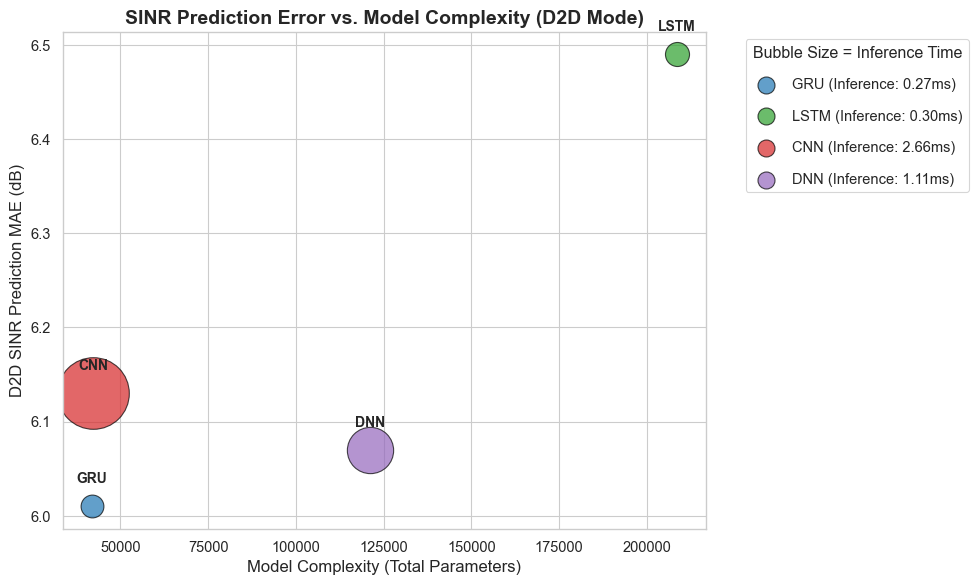

In [4]:
plt.figure(figsize=(10, 6))

valid_df = df.dropna(subset=['Params', 'D2D MAE', 'Inference (ms)'])
size_multiplier = 1000

for model in valid_df.index:
    plt.scatter(
        valid_df.loc[model, 'Params'],   # pyright: ignore[reportArgumentType]
        valid_df.loc[model, 'D2D MAE'],  # pyright: ignore[reportArgumentType]
        s=valid_df.loc[model, 'Inference (ms)'] * size_multiplier,  # type: ignore
        alpha=0.7, 
        c=colors.get(model.lower(), '#808080'), # Safe color fallback
        edgecolors='black',
        label=f"{model.upper()} (Inference: {valid_df.loc[model, 'Inference (ms)']:.2f}ms)"
    )

for model in valid_df.index:
    plt.text(
        valid_df.loc[model, 'Params'],  # pyright: ignore[reportArgumentType]
        valid_df.loc[model, 'D2D MAE'] + 0.025,   # type: ignore
        model.upper(), 
        fontsize=10, 
        ha='center', 
        fontweight='bold'
    )

plt.title('SINR Prediction Error vs. Model Complexity (D2D Mode)', fontsize=14, fontweight='bold')
plt.xlabel('Model Complexity (Total Parameters)', fontsize=12)
plt.ylabel('D2D SINR Prediction MAE (dB)', fontsize=12)
lgnd = plt.legend(title='Bubble Size = Inference Time', bbox_to_anchor=(1.05, 1), loc='upper left', labelspacing=1.2)
for handle in lgnd.legend_handles:
    handle.set_sizes([150])  # type: ignore
plt.tight_layout()
plt.savefig('../results/preprocessed_proposal/tradeoff_accuracy_complexity.png', dpi=300)
plt.show()

### Comparison of Average Throughput and Switching Rate between ML Models
A plot of average throughput (Mbps) and switching rate (%) between D2D and Cellular modes against different DL models (GRU, LSTM, CNN, and Feed-Forward DNN) are plotted. 
- Higher average throughput -> Better

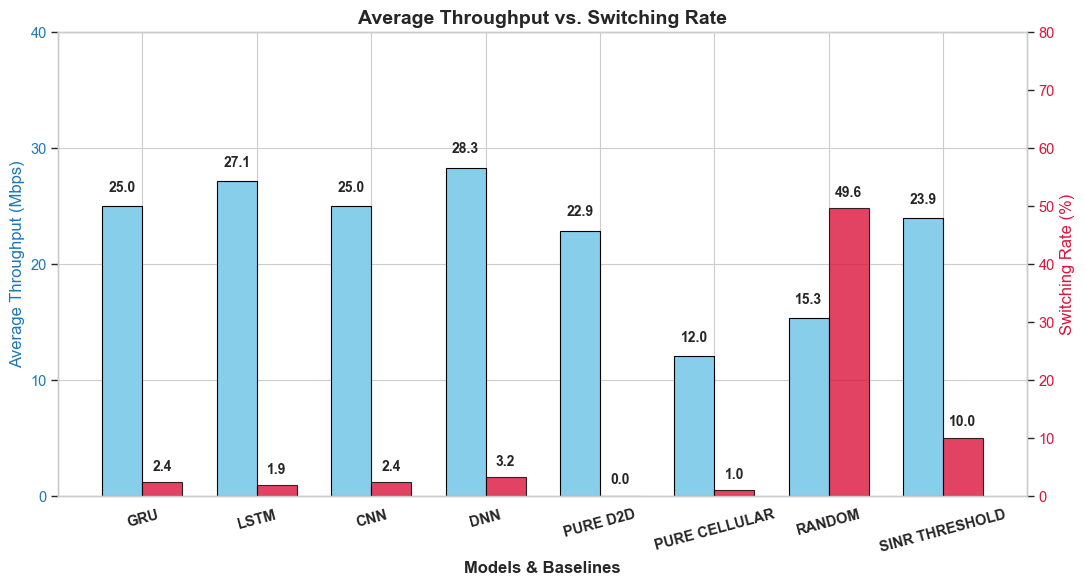

In [5]:
fig, ax1 = plt.subplots(figsize=(11, 6)) # Made slightly wider to fit side-by-side bars

# X-axis setup
x = np.arange(len(df.index))
width = 0.35 # Narrower width to fit two bars side-by-side

# Primary Axis: Average Throughput (Shifted Left)
bars1 = ax1.bar(x - width/2, df['Avg Tput (Mbps)'], width, color='skyblue', edgecolor='black', label='Avg Throughput (Mbps)')
ax1.set_xlabel('Models & Baselines', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Throughput (Mbps)', fontsize=12, color='tab:blue')
ax1.set_xticks(x)
# Format baseline names nicely 
ax1.set_xticklabels([m.replace('_', ' ').upper() for m in df.index], rotation=15, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Lock Axis 1 to exactly 6 proportional ticks (0 to 40)
ax1.set_ylim(0, 40)
ax1.set_yticks(np.arange(0, 41, 10))

# Secondary Axis: Switch Rate (Shifted Right)
ax2 = ax1.twinx()
# Replaced plot() with bar() and shifted to the right
bars2 = ax2.bar(x + width/2, df['Switch Rate (%)'], width, color='crimson', edgecolor='black', alpha=0.8, label='Switch Rate (%)')
ax2.set_ylabel('Switching Rate (%)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Lock Axis 2 to exactly 6 proportional ticks (0 to 80)
ax2.set_ylim(0, 80)
ax2.set_yticks(np.arange(0, 81, 10))
ax2.grid(False) # Keep secondary grid off so only ax1's clean grid shows

# Add values on top of Throughput bars
for bar in bars1:
    yval = bar.get_height()
    if pd.notna(yval): # Safe check for NaN
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add values on top of Switching Rate bars
for bar in bars2:
    yval = bar.get_height()
    if pd.notna(yval): # Safe check for NaN
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Average Throughput vs. Switching Rate', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('../results/preprocessed_proposal/tradeoff_throughput_stability.png', dpi=300)
plt.show()

# Radar Chart of Prediction Error, Complexity, Switching Rate, and Average Throughput for DL Models
Plotted a radar chart of prediction error (MAE in dB), switching rate (%), average throughput (Mbps), and complexity (number of parameters). These metrics are normalized for easier visualization. 
- Larger area of shape -> Better

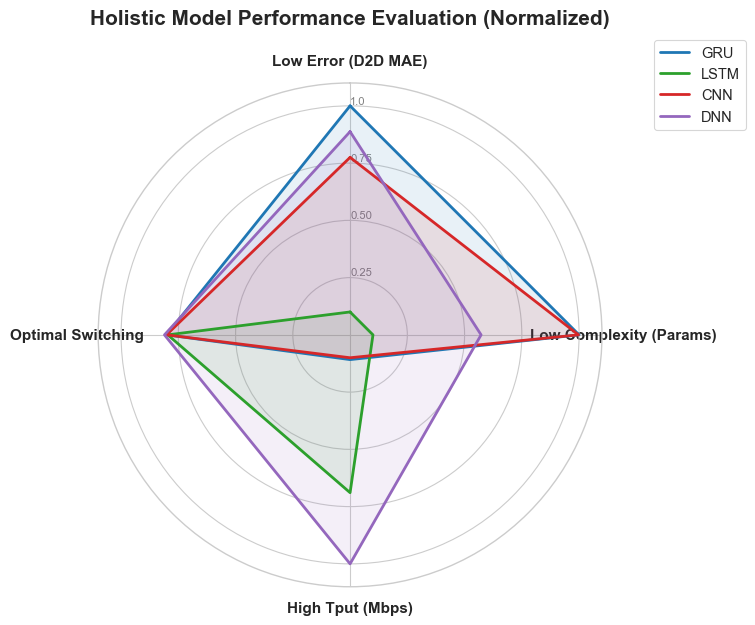

In [ ]:
# Helper function to prevent polygon collapse by mapping to 0.1 - 1.0
def min_max_scale(series, invert=False):
    scaled = (series - series.min()) / (series.max() - series.min())
    if invert:
        scaled = 1 - scaled
    return 0.1 + (scaled * 0.9) # Base radius of 0.1

valid_df = df.dropna(subset=['D2D MAE', 'Params', 'Avg Tput (Mbps)', 'Switch Rate (%)'])
df_norm = pd.DataFrame(index=valid_df.index)

# Apply safe normalization
df_norm['Low Error (D2D MAE)'] = min_max_scale(valid_df['D2D MAE'], invert=True)
df_norm['Low Complexity (Params)'] = min_max_scale(valid_df['Params'], invert=True)
df_norm['High Tput (Mbps)'] = min_max_scale(valid_df['Avg Tput (Mbps)'], invert=False)

# Optimal switching penalty (Safe mapping)
optimal_switch = 5.0
switch_penalty = abs(valid_df['Switch Rate (%)'] - optimal_switch) / max(optimal_switch, 100 - optimal_switch)
df_norm['Optimal Switching'] = 0.1 + ((1 - switch_penalty) * 0.9)

# Radar Chart Setup
categories = list(df_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(pi / 2) # pyright: ignore[reportAttributeAccessIssue]
ax.set_theta_direction(-1) # pyright: ignore[reportAttributeAccessIssue]
plt.xticks(angles[:-1], categories, size=11, fontweight='bold')
ax.set_rlabel_position(0) # pyright: ignore[reportAttributeAccessIssue]
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.0"], color="grey", size=8)
plt.ylim(0, 1.1)

# Plot each model
for model in df_norm.index:
    values = df_norm.loc[model].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model.upper(), color=colors[model])
    ax.fill(angles, values, color=colors[model], alpha=0.1)

plt.title('Holistic Model Performance Evaluation (Normalized)', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../results/preprocessed_proposal/tradeoff_radar_chart.png', dpi=300)
plt.show()